# Consultas a **Hive** por **consola**

Vamos a ver cómo lanzar consultas a Hive por consola.

Necesitaremos crear entonces un nuevo cluster Dataproc, porque el anterior lo eliminamos!!!

## ¡Recordemos!
Dataproc es un **servicio gestionado** que facilita la **ejecución de cargas de trabajo de procesamiento de datos en la nube** utilizando las herramientas del ecosistema de **Apache Hadoop**.

Es decir, Dataproc es un servicio para crear **clusters** que traen preinstalado el ecosistema **Hadoop**. Y entre otras muchas cosas, **Hive** es parte de **Hadoop**. Y por eso necesitamos tener un cluster Dataproc.

¿Os atrevéis a crear el cluster vosotros? **¿Alguien me ayuda?**

Una vez creado el cluster...

## Abrimos la **consola** de la máquina **master**

(Esto de entrar a la máquina directamente ya lo hicimos también 👀)

**¿Alguien se acuerda?**

## Una vez dentro de la máquina, vamos a conectarnos a Hive:

```bash
beeline -u jdbc:hive2://localhost:10000
```
Deberá mostrarnos algo así:

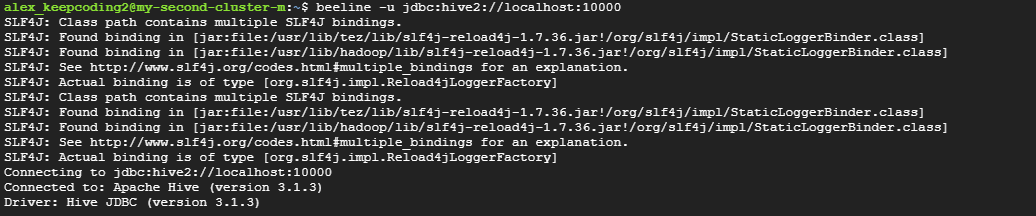



### Veamos el comando por partes:



*   **beeline**: Es la interfaz de linea de comandos que utilizaremos para interactuar con HiveServer2, que es el servicio SQL para Hive
*   **-u**: Especificamos la URL de conexión JDBC que Beeline usará
*   **jdbc:hive2://**: Le decimos que utilizaremos el protocolo JDBC para conectarnos a HiveSrver2 (Recordemos que ya vimos el protocolo JDBC en la teoría)
*   **localhost**: Estamos dentro de la máquina, y nos queremos conectar al servidor HiveServer2 que está dentro de la máquina, así que localhost.
*   **10000**: Es el puerto predeterminado por el que escucha HiveServer2


Con esto, **ya tenemos abierta la conexión con Hive**.

Aquí está la wiki de Beeline: https://cwiki.apache.org/confluence/display/Hive/HiveServer2+Clients


# Lanzemos algunas **consultas** sencillas!

### Mostrar tablas:

```
show tables;
```

#### Crear tabla:
```
CREATE TABLE alumnos (id INT, name STRING, last_name STRING);
```

#### Insertar datos:

```
INSERT INTO alumnos values(1, 'Francisco', 'Pérez'), (2, 'Miguel', 'Hernández');

INSERT INTO alumnos values(3, 'Samus', 'Aran'), (4, 'Donkey', 'Kong');

```

#### Queries:

```
SELECT * from alumnos;
```

#### Insertar muchos datos:

Vamos a crear un fichero csv con sudo y a meterle datos

```
ctrl+c (salir de beeline)
sudo apt update
sudo apt install nano -y
nano profesores.csv
```

Escribimos:
```
1,maria,vargas,mates
2,julio,perez,fisica
3,sandra,martinez,quimica
```  

Teclear `[ctr]x + y + enter` para salir de nano, y luego ejecutar

El delimitador por defecto en HIVE es un caracter de ASCII no estandar (^A), por lo tanto si queremos importar un `csv` tendriamos que crear una tabla indicando el delimitador.

```
beeline -u jdbc:hive2://localhost:10000

CREATE TABLE profesores (id INT, name STRING, last_name STRING, asignatura STRING) ROW FORMAT DELIMITED FIELDS TERMINATED BY ',';

LOAD DATA LOCAL INPATH '/home/XXXX/profesores.csv' INTO TABLE profesores;

```

**Tip:** Si no sé cuál es la ruta exacta del fichero o mi nombre de usuario, puedo hacer:

```
echo $HOME
```
Esto me devolverá la ruta.

**¡Atención!**

En ocasiones, puede haber problemas para cargar directamente el fichero desde el sistema de ficheros local, por lo que es necesario copiarlo primero a HDFS y subirlo desde ahí.

Para eso, necesitamos hacer lo siguiente:

1- Crear un directorio en HDFS para el usuario

```
hdfs dfs -mkdir -p /user/XXXX
```

2- Copiar el fichero a HDFS

```
hdfs dfs -put /home/alex_keepcoding2/profesores.csv /user/alex_keepcoding2/profesores.csv

```

3- Verificar que el archivo se ha copiado en HDFS

```
hdfs dfs -ls /user/alex_keepcoding2/
```

Ahora sí, vamos a cargar el archivo en la nueva tabla que creamos en Hive:

```
beeline -u jdbc:hive2://localhost:10000

CREATE TABLE profesores (id INT, name STRING, last_name STRING, asignatura STRING) ROW FORMAT DELIMITED FIELDS TERMINATED BY ',';

LOAD DATA INPATH '/user/alex_keepcoding2/profesores.csv' INTO TABLE profesores;
```

Hagamos un select para ver el resultado:

```
SELECT * from profesores;
```

### Extraer datos a HDFS (Desde la base de datos):


```
INSERT OVERWRITE DIRECTORY 'output' SELECT * FROM profesores;

ctrl+c
hdfs dfs -ls -R / | grep output
hdfs dfs -cat /user/anonymous/output/*
```

Desglosemos lo que está pasando aquí ⬆⬆⬆

- **INSERT OVERWRITE DIRECTORY 'output' SELECT * FROM profesores;**: Aquí le estamos diciendo a Hive que seleccione todos los datos de la tabla "profesores" y los inserte en un directorio en HDFS llamado "output". El uso de "overwrite" implica que si ya existe el directorio "output", será sobreescrito.

- **hdfs dfs -ls -R / | grep output**: Este comando HDFS lista de forma recursiva todo el contenido de HDFS y después "grep" filtra y muestra solo los que contengan la palabra "output".

- hdfs dfs -cat /user/anonymous/output/* : Aquí nos va a mostrar el contenido del directorio output.

Esto seguramente, habrá perdido el delimitador de columnas (la coma en nuestro caso), por lo que deberemos indicar en la query el delimitador:

```
INSERT OVERWRITE DIRECTORY 'output' ROW FORMAT DELIMITED FIELDS TERMINATED BY ',' SELECT * FROM profesores;

ctrl+c

hdfs dfs -cat /user/anonymous/output/*
```

Ahora sí que ha escrito el fichero con el delimitador correcto 👌.

Otra cosa más que podemos hacer es realizar **Extracciones** hacia **buckets de Google Storage**. Por ejemplo:

(Sustituir `XXXX` con el nombre del bucket)
```
INSERT OVERWRITE DIRECTORY 'gs://XXXXXX/output' ROW FORMAT DELIMITED FIELDS TERMINATED BY ',' SELECT * FROM alumnos;
```

## Recordemos un poquito de documentación

La cantidad de comandos que existen es muy grande (modificación de tablas, distintas posibilidades con joins, funciones...). Este es un buen sitio para tener una guía de la cuál poder tirar 🙂:

https://cwiki.apache.org/confluence/display/Hive/HiveServer2+Clients#HiveServer2Clients-BeelineExample

También existe una wiki con diferentes propiedades de configuración que pueden servirnos en función del proyecto al que nos enfrentemos:

https://cwiki.apache.org/confluence/display/Hive/Configuration+Properties